In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV,GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('E:\DATA SCIENCE\MACHINE-LEARNING\BOOSTING-TECHNIQUES\XGBOOST\SPOTIFY\DATA\dataset.csv')
pd.set_option('display.max_columns',21)

In [3]:
df

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [4]:
df.track_genre.value_counts().head(50)

track_genre
acoustic             1000
punk-rock            1000
progressive-house    1000
power-pop            1000
pop                  1000
pop-film             1000
piano                1000
party                1000
pagode               1000
opera                1000
new-age              1000
mpb                  1000
minimal-techno       1000
metalcore            1000
metal                1000
mandopop             1000
malay                1000
latino               1000
latin                1000
kids                 1000
k-pop                1000
jazz                 1000
j-rock               1000
j-pop                1000
j-idol               1000
j-dance              1000
iranian              1000
psych-rock           1000
punk                 1000
afrobeat             1000
r-n-b                1000
turkish              1000
trip-hop             1000
trance               1000
techno               1000
tango                1000
synth-pop            1000
swedish              1000


In [5]:
df1 = df[df['track_genre'].isin(['pop', 'country', 'hip-hop', 'punk-rock', 'latin', 'edm'])]

In [6]:
df1

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
19000,19000,2wrJq5XKLnmhRXHIAf9xBa,Dan + Shay;Justin Bieber,"10,000 Hours (with Justin Bieber)","10,000 Hours (with Justin Bieber)",78,167693,False,0.654,0.630,10,-4.644,1,0.0259,0.153000,0.000000,0.1110,0.430,89.991,4,country
19001,19001,6AHJTA1BN7ePfChCwqph3z,Luke Bryan,Country USA,Country On,0,236455,False,0.520,0.751,5,-5.064,1,0.0551,0.171000,0.000007,0.0624,0.519,156.044,4,country
19002,19002,5eUtyONoPyfZYGrFHmZzlc,Thomas Rhett,Mientras hago aromaterapia,Die A Happy Man,1,228320,False,0.590,0.389,2,-9.245,1,0.0387,0.411000,0.000001,0.1170,0.389,166.055,4,country
19003,19003,1e3QZ42GsP8cTy5uQ0G7J3,Zach Bryan,New Country,Something in the Orange,3,228013,False,0.369,0.192,4,-12.151,0,0.0400,0.555000,0.000008,0.0954,0.148,175.212,3,country
19004,19004,5Vnx0s7H73V3l6qPWvbHIM,Zach Bryan,Easy Country,Something in the Orange,4,228013,False,0.369,0.192,4,-12.151,0,0.0400,0.555000,0.000008,0.0954,0.148,175.212,3,country
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85995,85995,2K08WKliY0Bj44u7GW7JFz,Tequila Baby,Punk Rock Até Os Ossos,Planos Perfeitos,34,201906,False,0.357,0.962,9,-4.661,1,0.0703,0.000216,0.031600,0.0469,0.616,178.140,4,punk-rock
85996,85996,10LC9o0unUvjoSaMDsPOP9,Rybičky 48,Jedeme dál,"Tyvole, já budu táta",35,223530,False,0.755,0.603,7,-5.473,1,0.0389,0.013400,0.000000,0.0837,0.875,115.028,4,punk-rock
85997,85997,0NRvUoUnHaMXgyBB65bh7O,Plebe Rude,O Concreto Já Rachou,Minha Renda,35,158266,False,0.404,0.899,4,-8.130,0,0.1010,0.016900,0.000001,0.3100,0.633,195.332,4,punk-rock
85998,85998,3uVCGFrljwSIhWhQDtcTNK,Soda Stereo,Ruido Blanco (Remastered),Signos - Remasterizado 2007,35,380373,False,0.584,0.858,7,-7.173,1,0.0350,0.211000,0.039600,0.7100,0.163,125.864,4,punk-rock


In [7]:
df1.drop(columns=["Unnamed: 0", "track_id", "track_name", "artists", "album_name", "time_signature"], axis=1, inplace=True)

In [8]:
df1

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_genre
19000,78,167693,False,0.654,0.630,10,-4.644,1,0.0259,0.153000,0.000000,0.1110,0.430,89.991,country
19001,0,236455,False,0.520,0.751,5,-5.064,1,0.0551,0.171000,0.000007,0.0624,0.519,156.044,country
19002,1,228320,False,0.590,0.389,2,-9.245,1,0.0387,0.411000,0.000001,0.1170,0.389,166.055,country
19003,3,228013,False,0.369,0.192,4,-12.151,0,0.0400,0.555000,0.000008,0.0954,0.148,175.212,country
19004,4,228013,False,0.369,0.192,4,-12.151,0,0.0400,0.555000,0.000008,0.0954,0.148,175.212,country
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85995,34,201906,False,0.357,0.962,9,-4.661,1,0.0703,0.000216,0.031600,0.0469,0.616,178.140,punk-rock
85996,35,223530,False,0.755,0.603,7,-5.473,1,0.0389,0.013400,0.000000,0.0837,0.875,115.028,punk-rock
85997,35,158266,False,0.404,0.899,4,-8.130,0,0.1010,0.016900,0.000001,0.3100,0.633,195.332,punk-rock
85998,35,380373,False,0.584,0.858,7,-7.173,1,0.0350,0.211000,0.039600,0.7100,0.163,125.864,punk-rock


In [9]:
df1.dtypes

popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
track_genre          object
dtype: object

In [10]:
c = []
for i in df1.columns:
    if df1[i].dtypes == 'object':
        c.append(i)
c

['track_genre']

In [11]:
for i in c:
    print(i)
    print(df1[i].unique())
    print(df1[i].value_counts())

track_genre
['country' 'edm' 'hip-hop' 'latin' 'pop' 'punk-rock']
track_genre
country      1000
edm          1000
hip-hop      1000
latin        1000
pop          1000
punk-rock    1000
Name: count, dtype: int64


In [12]:
df1.isnull().sum()

popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
track_genre         0
dtype: int64

In [13]:
x = df1.drop('track_genre',axis = 1)
y = df1.track_genre

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3,random_state = 99,stratify = y)

In [15]:
y_train.value_counts()

track_genre
pop          700
country      700
punk-rock    700
latin        700
hip-hop      700
edm          700
Name: count, dtype: int64

In [16]:
y_test.value_counts()

track_genre
country      300
latin        300
edm          300
pop          300
punk-rock    300
hip-hop      300
Name: count, dtype: int64

In [17]:
scaler = StandardScaler()
scaler

StandardScaler()

In [18]:
x_train = scaler.fit_transform(x_train)

In [19]:
x_test = scaler.fit_transform(x_test)

In [20]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)

In [21]:
model = xgb.XGBClassifier()
model 

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [22]:
model.fit(x_train,y_train)
model.score(x_train,y_train)

0.9604761904761905

In [23]:
model.score(x_test,y_test)

0.6766666666666666

In [24]:
y_pred = model.predict(x_test)

In [25]:
cm = confusion_matrix(y_test,y_pred)

<Axes: >

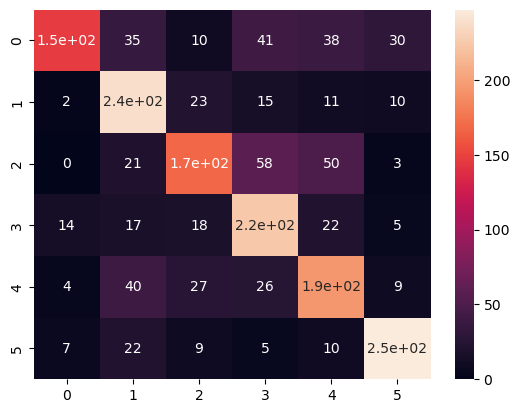

In [26]:
sns.heatmap(cm,annot = True)

In [27]:
# param_grid = {
#     'n_estimators': [100, 200, 300, 500],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'max_depth': [3, 6, 9],
#     'min_child_weight': [1, 3, 5],
#     'subsample': [0.7, 0.85, 1.0],
#     'colsample_bytree': [0.7, 0.85, 1.0],
#     'reg_alpha': [0, 0.01, 0.1, 1, 10, 100],
#     'reg_lambda': [0.5, 0.7, 1, 1.3]
# }


In [36]:
param_grid = {
    'n_estimators':[100,200,250,300],
    'learning_rate':[0.1,0.001,0.002],
    'gamma' : [10,5,20,25],'max_depth': [3, 6, 9]
}

xgb_model = xgb.XGBClassifier(random_state=42)

grid_search = GridSearchCV(xgb_model, param_grid, cv=5)
grid_search.fit(x_train, y_train)

best_xgb = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)


Best Parameters: {'gamma': 5, 'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 100}
Best Accuracy: 0.6807142857142858


In [37]:
best_xgb

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=5, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [38]:
y_pred = best_xgb.predict(x_test)

In [39]:
accuracy_score(y_test,y_pred)

0.6316666666666667

In [48]:
feature_importances = best_xgb.feature_importances_
feature_names = x.columns

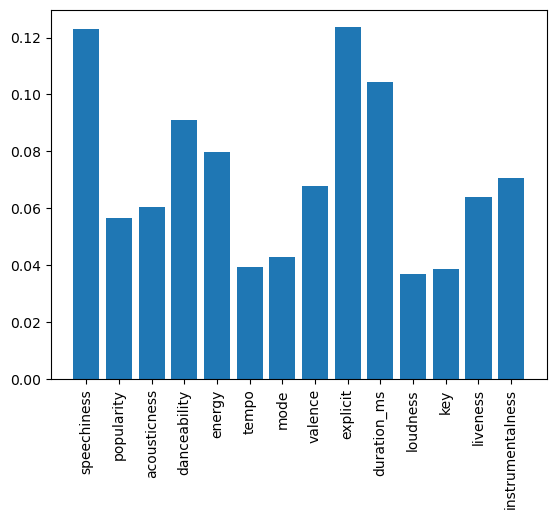

In [50]:
sorted_indices = np.argsort(feature_importances)[::-1]
plt.bar(range(len(feature_importances)),feature_importances,align = 'center')
plt.xticks(range(len(feature_importances)), np.array(feature_names)[sorted_indices], rotation=90)
plt.show()